In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [9]:
file_path = "/content/covid_data.csv"
df = pd.read_csv(file_path, parse_dates=["date"])
df.head()

,location,date,new_cases,total_cases,new_deaths,total_deaths,stringency_index
0,United States,2020-03-01,912,912,12,12,47.36
1,United States,2020-03-08,541,1453,7,19,41.99
2,United States,2020-03-15,723,2176,9,28,46.32
3,United States,2020-03-22,1038,3214,10,38,34.81
4,United States,2020-03-29,1093,4307,15,53,43.54


In [10]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   location          350 non-null    object        
 1   date              350 non-null    datetime64[ns]
 2   new_cases         350 non-null    int64         
 3   total_cases       350 non-null    int64         
 4   new_deaths        350 non-null    int64         
 5   total_deaths      350 non-null    int64         
 6   stringency_index  350 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(4), object(1)
memory usage: 19.3+ KB


,date,new_cases,total_cases,new_deaths,total_deaths,stringency_index
count,350,350.000000,350.000000,350.000000,350.000000,350.000000
mean,2020-10-28 12:00:00,2965.628571,116843.091429,36.231429,1419.462857,46.413486
min,2020-03-01 00:00:00,271.000000,912.000000,1.000000,12.000000,0.000000
25%,2020-06-28 00:00:00,1335.250000,38632.750000,15.000000,454.000000,29.215000
50%,2020-10-28 12:00:00,2709.500000,106364.500000,30.000000,1219.000000,42.460000
75%,2021-02-28 00:00:00,4125.500000,179444.750000,49.000000,2223.250000,54.307500
max,2021-06-27 00:00:00,8213.000000,341400.000000,143.000000,4108.000000,100.000000
std,NaN,1888.372222,86151.841001,27.023191,1074.346778,26.843030


In [11]:
numeric_cols = [c for c in ["new_cases", "total_cases", "new_deaths",
                             "total_deaths", "recovered", "stringency_index"]
                 if c in df.columns]
df[numeric_cols] = df[numeric_cols].fillna(0)
df = df.sort_values(["location", "date"])
df.isnull().sum()

,0
location,0
date,0
new_cases,0
total_cases,0
new_deaths,0
total_deaths,0
stringency_index,0


In [12]:
countries = df["location"].unique().tolist()
print("Available countries/regions:", countries)

selected_countries = countries  # or specify a list, e.g. ["India", "Brazil"]
subset = df[df["location"].isin(selected_countries)]

Available countries/regions: ['Brazil', 'Germany', 'India', 'United Kingdom', 'United States']


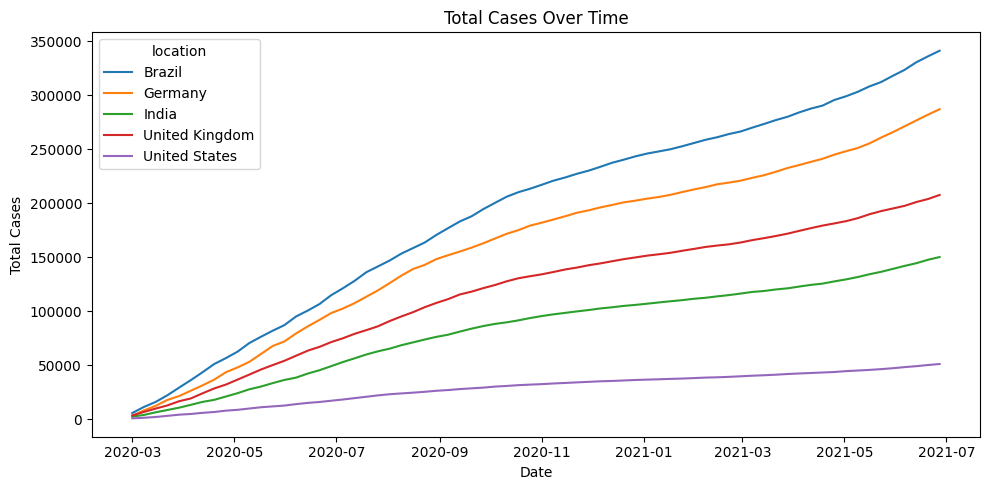

In [13]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=subset, x="date", y="total_cases", hue="location")
plt.title("Total Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Total Cases")
plt.tight_layout()
plt.show()

In [14]:
if "recovered" in df.columns:
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=subset, x="date", y="recovered", hue="location")
    plt.title("Recoveries Over Time")
    plt.xlabel("Date")
    plt.ylabel("Recovered Cases")
    plt.tight_layout()
    plt.show()
else:
    print("No 'recovered' column found in the dataset — skipping recovery trend plot.")

No 'recovered' column found in the dataset — skipping recovery trend plot.


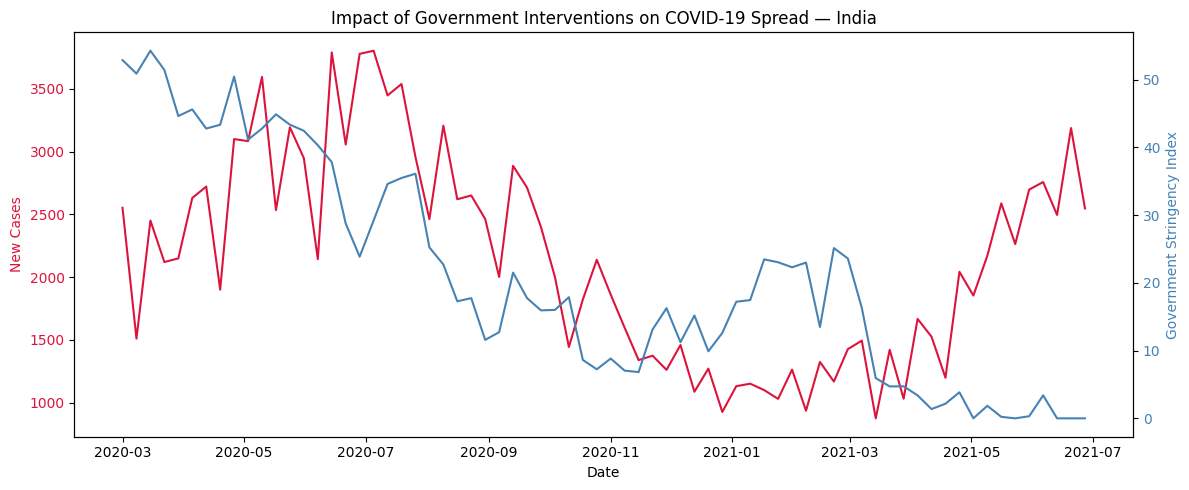

In [15]:
country = "India"
country_data = df[df["location"] == country]

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(country_data["date"], country_data["new_cases"], color="crimson", label="New Cases")
ax1.set_xlabel("Date")
ax1.set_ylabel("New Cases", color="crimson")
ax1.tick_params(axis="y", labelcolor="crimson")

ax2 = ax1.twinx()
ax2.plot(country_data["date"], country_data["stringency_index"], color="steelblue", label="Stringency Index")
ax2.set_ylabel("Government Stringency Index", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")

plt.title(f"Impact of Government Interventions on COVID-19 Spread — {country}")
fig.tight_layout()
plt.show()

In [16]:
fig = px.line(
    subset,
    x="date",
    y="total_cases",
    color="location",
    title="COVID-19 Total Cases Over Time (Interactive)"
)
fig.show()

In [17]:
fig = px.line(
    country_data,
    x="date",
    y=["new_cases", "stringency_index"],
    title=f"New Cases vs. Government Stringency Index — {country}"
)
fig.show()